In [1]:
import os

# Define the variables manually before running your code
os.environ['EXPERIMENT_ROOT'] = '/home/jing/Desktop/realistic-al/experiments'
os.environ['DATA_ROOT'] = '/home/jing/Desktop/realistic-al/datasets'

# Verify it worked
print(os.environ['EXPERIMENT_ROOT'])

/home/jing/Desktop/realistic-al/experiments


In [2]:
import sys
import torch
import numpy as np
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import seaborn as sns
import collections

# Add src and project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)
if project_root not in sys.path:
    sys.path.append(project_root)

from models.bayesian import BayesianModule
from run_training import get_torchvision_dm
from analysis.confusion import get_confusion_matrix
from utils import config_utils

print(f"Project Root: {project_root}")
print(f"Source Path: {src_path}")

/home/jing/anaconda3/envs/real-al/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/home/jing/anaconda3/envs/real-al/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/jing/anaconda3/envs/real-al/lib/python3.10/site-packages/pl_bolts/models/self_supe

Project Root: /home/jing/Desktop/realistic-al
Source Path: /home/jing/Desktop/realistic-al/src


/home/jing/anaconda3/envs/real-al/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Set Experiment Directory
# TODO: Replace with your actual experiment path
EXPERIMENT_DIR = '../experiments/activelearning/cifar10/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-vendi_ep-200/2026-01-12_14-26-11-010447'
CHECKPOINT_NAME = "loop-9/checkpoints/epoch=187-step=1128.ckpt" # or 'best.ckpt' if available

config_path = os.path.join(EXPERIMENT_DIR, ".hydra", "config.yaml")
checkpoint_path = os.path.join(EXPERIMENT_DIR, CHECKPOINT_NAME)

# Load Config
cfg = OmegaConf.load(config_path)

# Ensure data root is correct (taking from env or assuming a default structure if running locally)
if os.getenv("DATA_ROOT"):
    cfg.trainer.data_root = os.getenv("DATA_ROOT")
else:
    # Fallback or keep as is if it's absolute
    pass

print(f"Loaded config from: {config_path}")

Loaded config from: ../experiments/activelearning/cifar10/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-vendi_ep-200/2026-01-12_14-26-11-010447/.hydra/config.yaml


In [4]:
# Load Model
model = BayesianModule(cfg)

# Load Checkpoint using torch.load with weights_only=False to allow DictConfig
ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

# Load state dict
# Note: Lightning checkpoints have a 'state_dict' key
model.load_state_dict(ckpt['state_dict'], strict=False)
model = model.cuda()
model.eval()
print("Model loaded successfully")

2026-01-19 00:17:43.801 | INFO     | models.networks.bayesian_resnet:_get_basemodel:85 - Feature extractor: resnet18


Model loaded successfully


In [5]:
# Load Data
datamodule = get_torchvision_dm(cfg)
datamodule.prepare_data()
datamodule.setup(stage=None)
test_loader = datamodule.test_dataloader()
print("Data loaded successfully")

Data loaded successfully


In [6]:
# Calculate Confusion Matrix
conf_mat = get_confusion_matrix(model, test_loader)
print("Confusion Matrix shape:", conf_mat.shape)

Confusion Matrix shape: (10, 10)


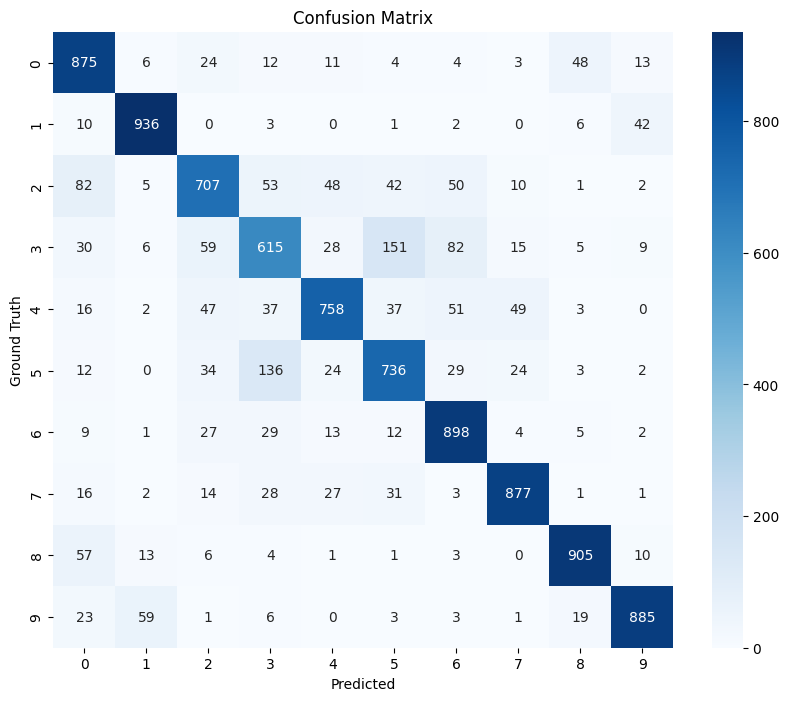

In [7]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Ground Truth')
plt.title(f'Confusion Matrix')
plt.show()

In [12]:
def cm_for_experiment(
    experiment_dir: str,
    normalize_type: str = None,
    
):
    """
    Get the confusion matrix for a specific experiment.
    model: final checkpoint from loop 9 of the experiment.
    data: test set of the experiment.

    Args:
        experiment_dir (str): Path to the experiment directory.
    """
    # Load config
    # Load model
        # Load checkpoint. There should only be one checkpoint in loop-9/checkpoints. Identify it and load it.
    # Load datamodule
    # Plot confusion matrix

    # Load config
    config_path = os.path.join(experiment_dir, ".hydra", "config.yaml")
    print(f"Loading config from: {config_path}")
    if not os.path.exists(config_path):
        print(f"Error: Config not found at {config_path}")
        return

    cfg = OmegaConf.load(config_path)
    
    # Load model
    print("Initializing model...")
    model = BayesianModule(cfg)
    
    # Find checkpoint
    ckpt_dir = os.path.join(experiment_dir, "loop-9", "checkpoints")

    ckpt_files = [f for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")]
    assert len(ckpt_files) == 1, f"Expected 1 checkpoint in {ckpt_dir}, found {len(ckpt_files)}"
    checkpoint_path = os.path.join(ckpt_dir, ckpt_files[0])
    
    print(f"Loading checkpoint from: {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['state_dict'], strict=False)
    model = model.cuda()
    model.eval()

    datamodule = get_torchvision_dm(cfg)
    datamodule.prepare_data()
    datamodule.setup(stage=None)
    test_loader = datamodule.test_dataloader()

    # Print dataset summary
    print(collections.Counter(test_loader.dataset.targets))

    conf_mat = get_confusion_matrix(model, test_loader, normalize_type=normalize_type)
    
    return conf_mat

def plot_confusion_matrix(conf_mat, title: str="Confusion Matrix"):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_mat, annot=True, fmt='.2f' if np.issubdtype(conf_mat.dtype, np.floating) else 'd', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.title(title)
    plt.show()

In [11]:
isinstance(np.int64, int)

False

In [9]:
conf_mat = cm_for_experiment("/home/jing/Desktop/realistic-al/experiments/vending")
base_dir = '/home/jing/Desktop/realistic-al/experiments/activelearning'

cms = []

for exp in [
    'cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-vendi-l2_ep-200__wloss-True/2026-01-03_18-00-42-615705',
    'cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-random_ep-200__wloss-True/2026-01-04_01-44-56-819039',
    'cifar10/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-vendi_ep-200/2026-01-12_14-26-11-010447',
    'cifar10/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-random_ep-200/2026-01-15_02-41-12-449772'
]:
    exp_dir = os.path.join(base_dir, exp)
    cm = cm_for_experiment(exp_dir, normalize_type='true')
    cms.append(cm)

Loading config from: /home/jing/Desktop/realistic-al/experiments/vending/.hydra/config.yaml
Error: Config not found at /home/jing/Desktop/realistic-al/experiments/vending/.hydra/config.yaml
Loading config from: /home/jing/Desktop/realistic-al/experiments/activelearning/cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-vendi-l2_ep-200__wloss-True/2026-01-03_18-00-42-615705/.hydra/config.yaml
Initializing model...


2026-01-19 00:17:49.548 | INFO     | models.networks.bayesian_resnet:_get_basemodel:85 - Feature extractor: resnet18


Loading checkpoint from: /home/jing/Desktop/realistic-al/experiments/activelearning/cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-vendi-l2_ep-200__wloss-True/2026-01-03_18-00-42-615705/loop-9/checkpoints/epoch=178-step=1074.ckpt
Class 0 - Needed Samples: 4500 - Real Samples 4488
Class 1 - Needed Samples: 2913 - Real Samples 2913
Class 2 - Needed Samples: 1886 - Real Samples 1886
Class 3 - Needed Samples: 1221 - Real Samples 1221
Class 4 - Needed Samples: 790 - Real Samples 790
Class 5 - Needed Samples: 512 - Real Samples 512
Class 6 - Needed Samples: 331 - Real Samples 331
Class 7 - Needed Samples: 214 - Real Samples 214
Class 8 - Needed Samples: 139 - Real Samples 139
Class 9 - Needed Samples: 90 - Real Samples 90
Class 0 : #Samples 4500
Class 1 : #Samples 2913
Class 2 : #Samples 1886
Class 3 : #Samples 1221
Class 4 : #Samples 790
Class 5 : #Samples 512
Class 6 : #Samples 331
Class 7 : #Samples 214
Class 8 : #Samples 139
Class 9 : #Samples 90
Cou

2026-01-19 00:18:14.222 | INFO     | models.networks.bayesian_resnet:_get_basemodel:85 - Feature extractor: resnet18


Loading checkpoint from: /home/jing/Desktop/realistic-al/experiments/activelearning/cifar10_imb/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-random_ep-200__wloss-True/2026-01-04_01-44-56-819039/loop-9/checkpoints/epoch=180-step=1086.ckpt
Class 0 - Needed Samples: 4500 - Real Samples 4488
Class 1 - Needed Samples: 2913 - Real Samples 2913
Class 2 - Needed Samples: 1886 - Real Samples 1886
Class 3 - Needed Samples: 1221 - Real Samples 1221
Class 4 - Needed Samples: 790 - Real Samples 790
Class 5 - Needed Samples: 512 - Real Samples 512
Class 6 - Needed Samples: 331 - Real Samples 331
Class 7 - Needed Samples: 214 - Real Samples 214
Class 8 - Needed Samples: 139 - Real Samples 139
Class 9 - Needed Samples: 90 - Real Samples 90
Class 0 : #Samples 4500
Class 1 : #Samples 2913
Class 2 : #Samples 1886
Class 3 : #Samples 1221
Class 4 : #Samples 790
Class 5 : #Samples 512
Class 6 : #Samples 331
Class 7 : #Samples 214
Class 8 : #Samples 139
Class 9 : #Samples 90
Count

2026-01-19 00:18:38.832 | INFO     | models.networks.bayesian_resnet:_get_basemodel:85 - Feature extractor: resnet18


Loading checkpoint from: /home/jing/Desktop/realistic-al/experiments/activelearning/cifar10/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-vendi_ep-200/2026-01-12_14-26-11-010447/loop-9/checkpoints/epoch=187-step=1128.ckpt
Counter({3: 1000, 8: 1000, 0: 1000, 6: 1000, 1: 1000, 9: 1000, 5: 1000, 7: 1000, 4: 1000, 2: 1000})
Loading config from: /home/jing/Desktop/realistic-al/experiments/activelearning/cifar10/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-random_ep-200/2026-01-15_02-41-12-449772/.hydra/config.yaml
Initializing model...


2026-01-19 00:18:42.475 | INFO     | models.networks.bayesian_resnet:_get_basemodel:85 - Feature extractor: resnet18


Loading checkpoint from: /home/jing/Desktop/realistic-al/experiments/activelearning/cifar10/active-cifar10_med/basic_model-resnet_drop-0_aug-cifar_randaugmentMC_acq-random_ep-200/2026-01-15_02-41-12-449772/loop-9/checkpoints/epoch=182-step=1098.ckpt
Counter({3: 1000, 8: 1000, 0: 1000, 6: 1000, 1: 1000, 9: 1000, 5: 1000, 7: 1000, 4: 1000, 2: 1000})


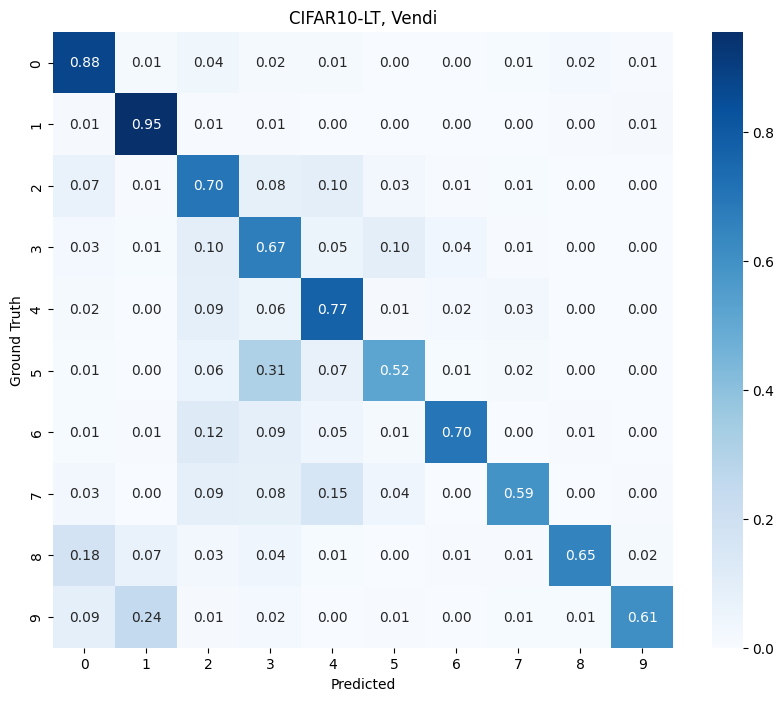

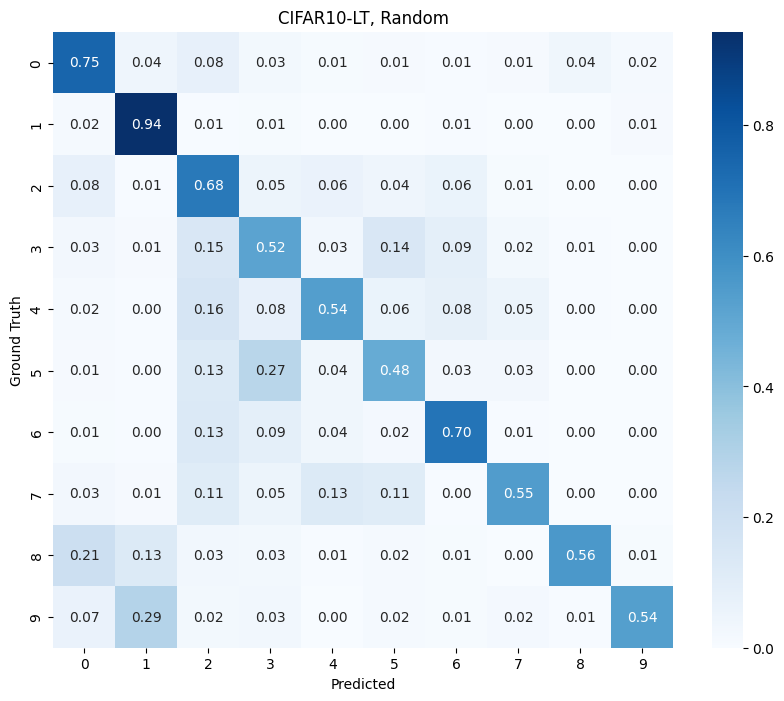

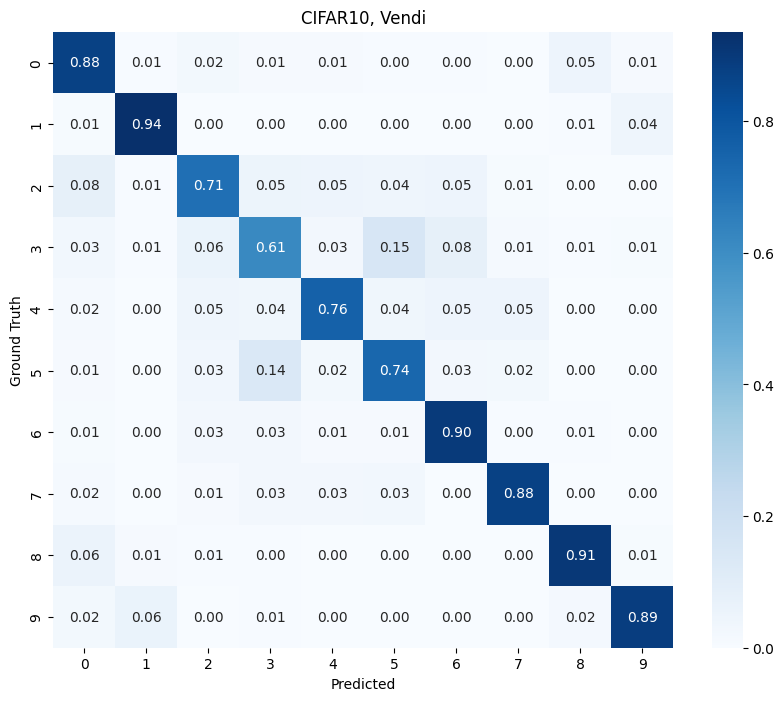

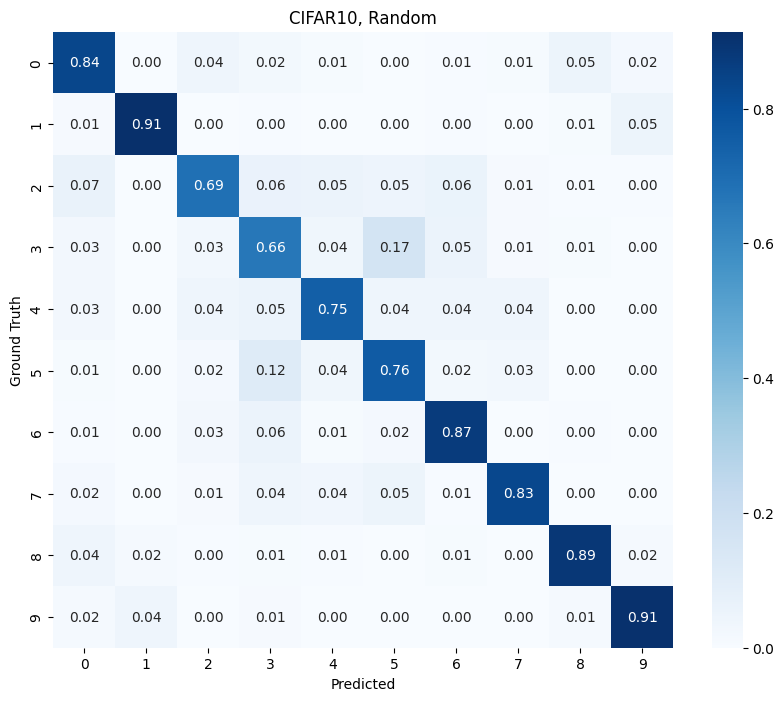

In [13]:
titles = [
    'CIFAR10-LT, Vendi',
    'CIFAR10-LT, Random',
    'CIFAR10, Vendi',
    'CIFAR10, Random'
]

for title, cm in zip(titles, cms):
    plot_confusion_matrix(cm, title=title)

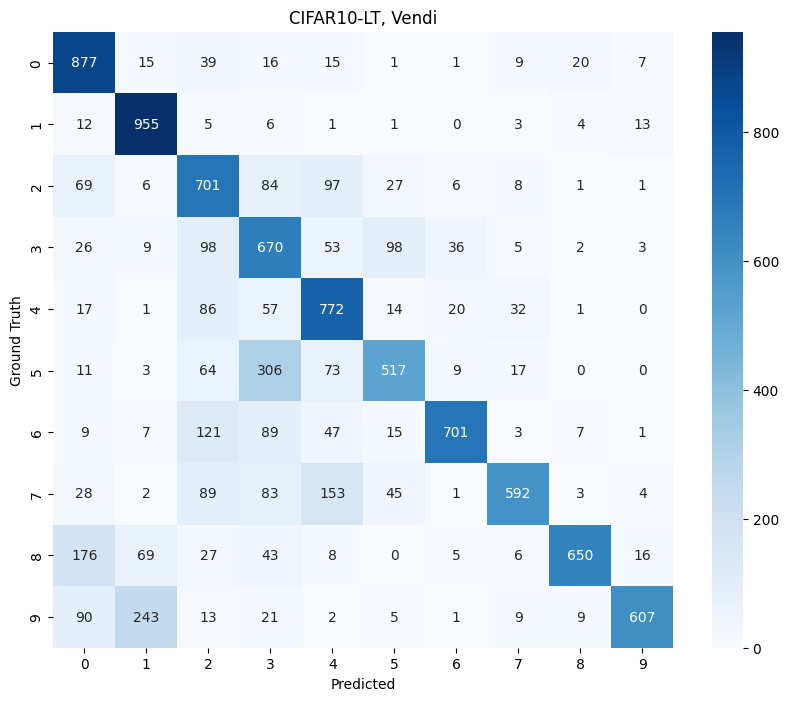

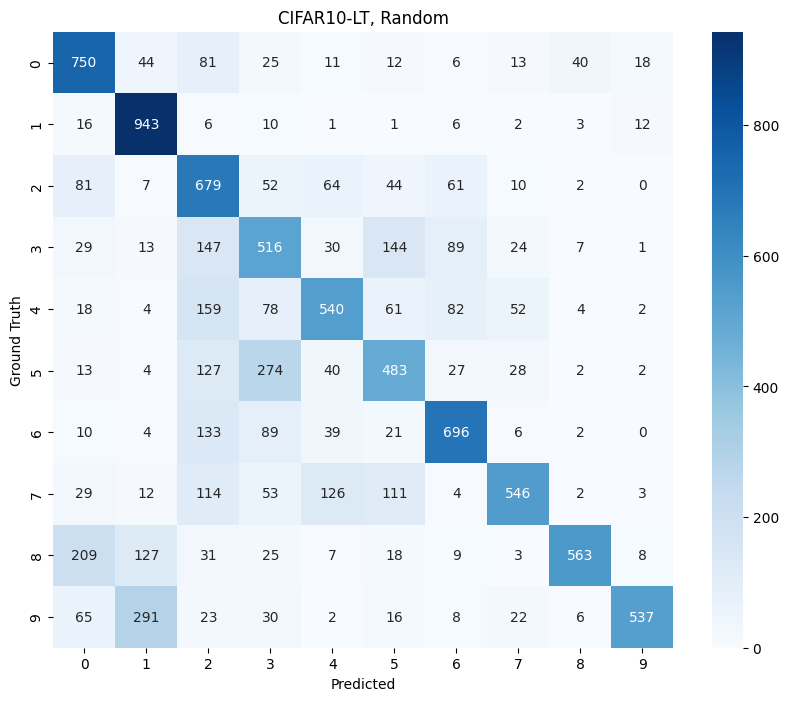

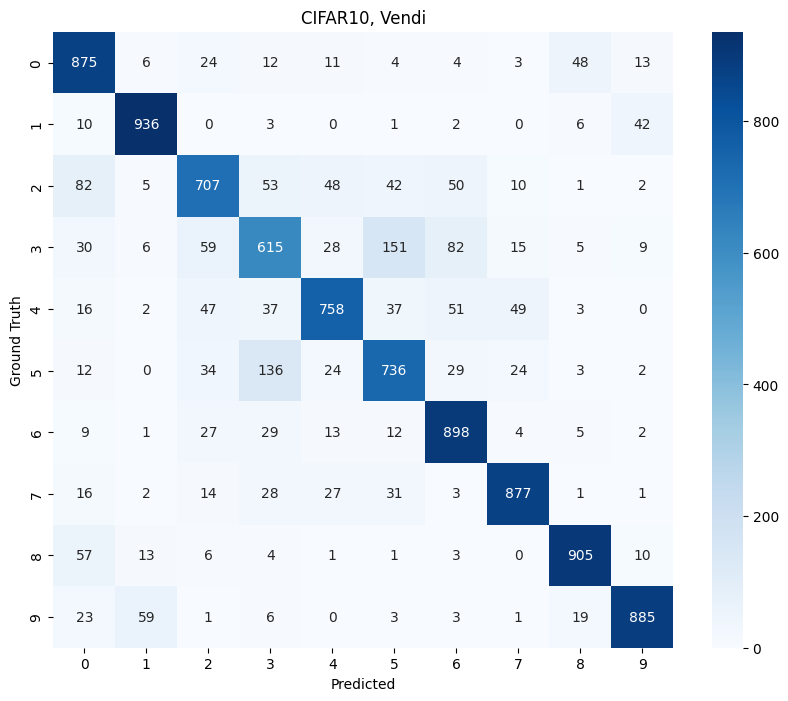

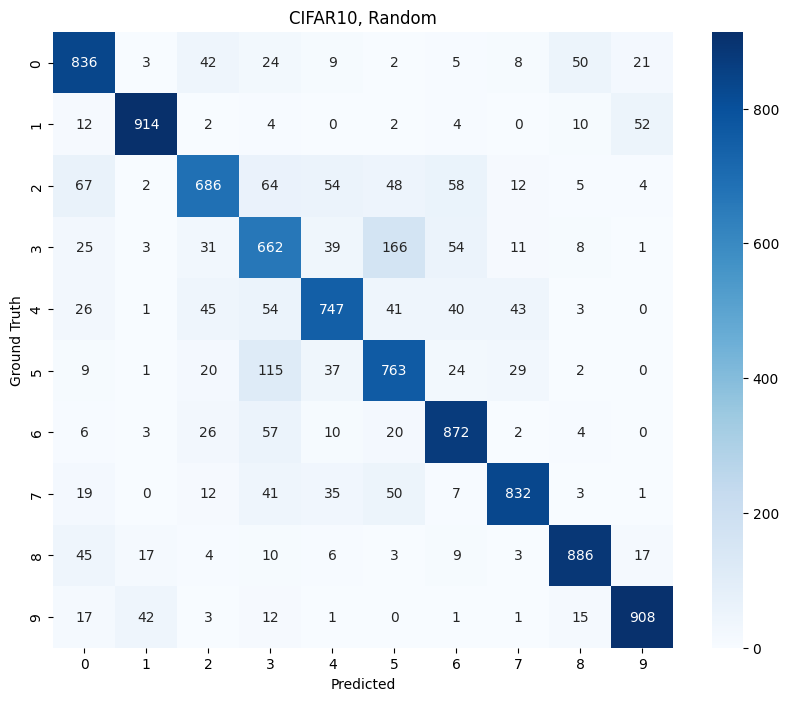

In [31]:
titles = [
    'CIFAR10-LT, Vendi',
    'CIFAR10-LT, Random',
    'CIFAR10, Vendi',
    'CIFAR10, Random'
]

for title, cm in zip(titles, cms):
    plot_confusion_matrix(cm, title=title)

In [19]:
test_set.classes[3], test_set.classes[5]

('cat', 'dog')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


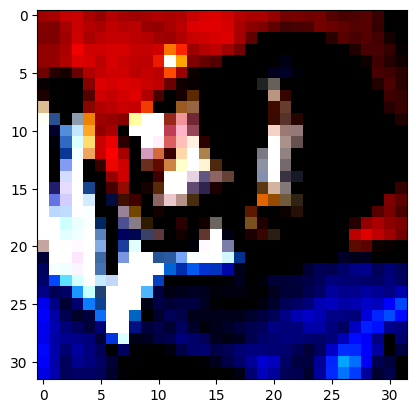

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


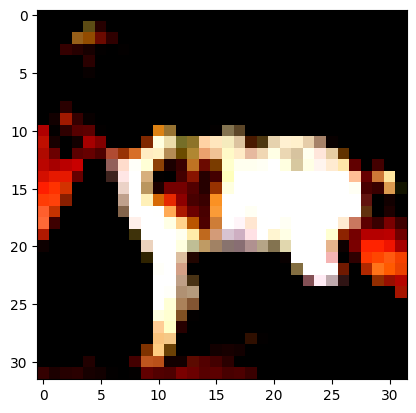

In [16]:
test_set = datamodule.test_set
test_set_3 = [x for x in test_set if x[1] == 3]
test_set_5 = [x for x in test_set if x[1] == 5]

sample_3 = test_set_3[0]
sample_5 = test_set_5[0]

plt.imshow(sample_3[0].permute(1, 2, 0))
plt.show()

plt.imshow(sample_5[0].permute(1, 2, 0))
plt.show()
